In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,mean_absolute_error,mean_squared_error,r2_score

In [8]:
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving corporate_greenskilling_v2.csv to corporate_greenskilling_v2.csv


,Employee_ID,Department,Training_Program,Hours_Completed,Training_Cost_USD,Certification_Status,Role_Shifted_Post_Training,Est_Carbon_Reduction_Tons_Yr
0,EMP-1000,Supply Chain,Solar PV Installation,81,3217.88,Certified,Yes,14.3
1,EMP-1001,Facilities,Carbon Accounting,42,2105.76,Certified,No,637.4
2,EMP-1002,Product Design,Circular Economy Basics,146,2361.57,Certified,No,235.3
3,EMP-1003,Supply Chain,Eco-Design,156,3022.42,Certified,No,729.5
4,EMP-1004,Finance,Circular Economy Basics,159,2319.65,Certified,No,774.0


In [9]:
num=df.select_dtypes(include='number').columns
cat=df.select_dtypes(exclude='number').columns
for c in num: df[c]=df[c].fillna(df[c].median())
for c in cat: df[c]=df[c].fillna(df[c].mode()[0])

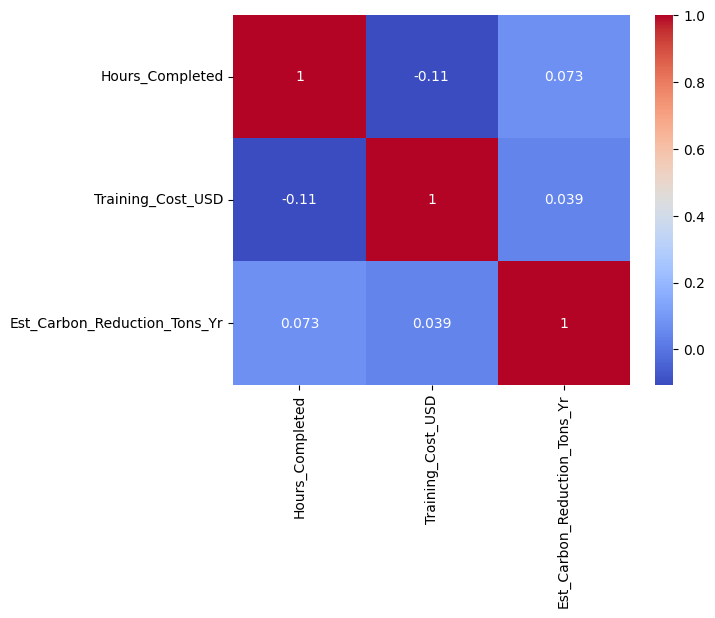

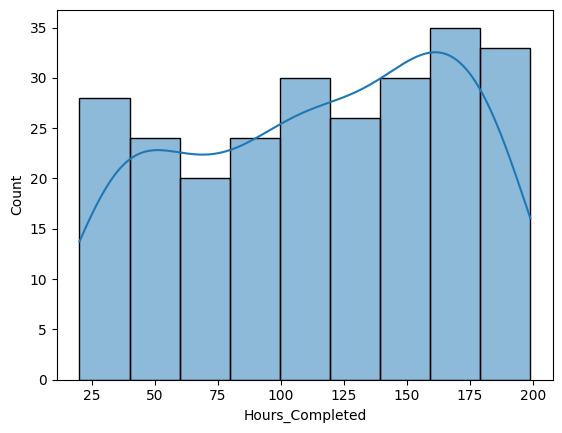

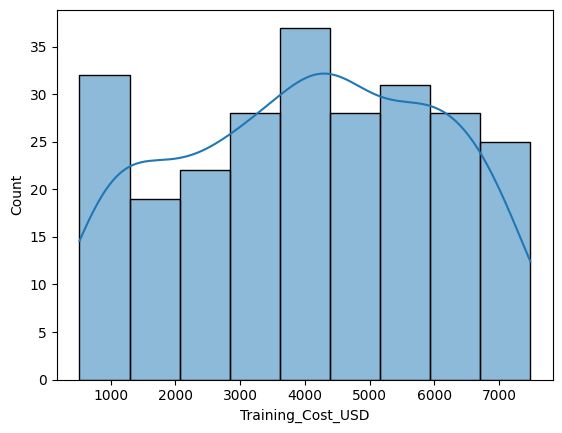

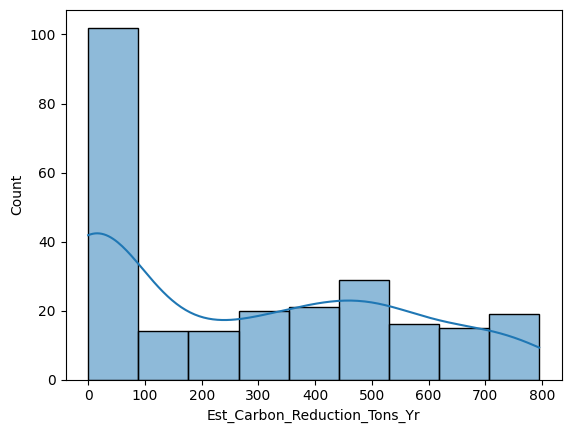

In [10]:
sns.heatmap(df[num].corr(),annot=True,cmap='coolwarm')
plt.show()
for c in num[:4]:
    sns.histplot(df[c],kde=True)
    plt.show()

In [12]:
df = pd.get_dummies(df, drop_first=True)

# Updated target to a column that actually exists in your data
target = 'Est_Carbon_Reduction_Tons_Yr'

X = df.drop(columns=[target])
y_reg = df[target]
y_cls = (y_reg >= y_reg.median()).astype(int)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Target set to: {target}")
print(f"Feature matrix shape: {X_scaled.shape}")

Target set to: Est_Carbon_Reduction_Tons_Yr
Feature matrix shape: (250, 266)


In [ ]:
# Split data for Regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

# Split data for Classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_scaled, y_cls, test_size=0.2, random_state=42)
cls_model = LogisticRegression()
cls_model.fit(X_train_c, y_train_c)
y_pred_c = cls_model.predict(X_test_c)

print("--- Regression Results ---")
print(f"MAE: {mean_absolute_error(y_test_r, y_pred_r):.2f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.2f}")

print("\n--- Classification Results ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.2%}")
print(classification_report(y_test_c, y_pred_c))

In [13]:
Xtr,Xte,yrtr,yrte=train_test_split(X,y_reg,test_size=0.2,random_state=42)
_,_,yctr,ycte=train_test_split(X,y_cls,test_size=0.2,random_state=42)

Accuracy 0.84
              precision    recall  f1-score   support

           0       0.89      0.73      0.80        22
           1       0.81      0.93      0.87        28

    accuracy                           0.84        50
   macro avg       0.85      0.83      0.83        50
weighted avg       0.85      0.84      0.84        50



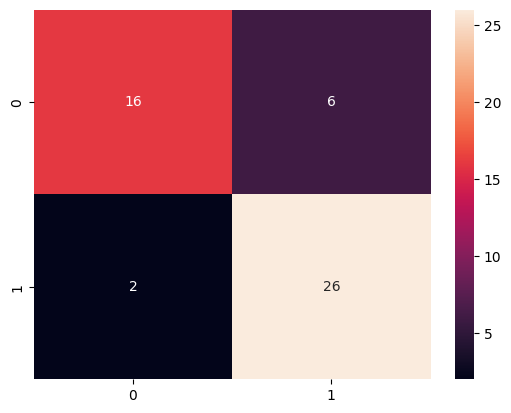

In [14]:
Xtr,Xte,ytr,yte=train_test_split(X,y_cls,test_size=0.2,random_state=42)
log=LogisticRegression(max_iter=1000)
log.fit(Xtr,ytr)
p=log.predict(Xte)
print('Accuracy',accuracy_score(yte,p))
print(classification_report(yte,p))
sns.heatmap(confusion_matrix(yte,p),annot=True,fmt='d')
plt.show()